In [4]:
!pip install gymnasium

In [5]:
%matplotlib inline

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import gymnasium as gym

# Environment setup
env = gym.make('CliffWalking-v1', render_mode=None)
n_states = env.observation_space.n
n_actions = env.action_space.n

# Increased episodes, added initial_epsilon, min_epsilon, and epsilon_decay
num_episodes=5000

def train_Q(env, alpha=0.2, gamma=0.99, initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, episodes=num_episodes, algo='qlearning'):
    Q = np.zeros((n_states, n_actions))
    epsilon = initial_epsilon
    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.choice(n_actions)
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if algo == 'sarsa':
                # SARSA is on-policy, so it uses the *next* action taken by the current (exploratory) policy
                if np.random.rand() < epsilon:
                    next_action = np.random.choice(n_actions)
                else:
                    next_action = np.argmax(Q[next_state])
                td_target = reward + gamma * Q[next_state, next_action] * (not done)
            else:  # Q-learning (DQN-style off-policy update)
                # Q-learning is off-policy, it considers the best possible action from next_state
                td_target = reward + gamma * np.max(Q[next_state]) * (not done)
            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state
        epsilon = max(min_epsilon, epsilon * epsilon_decay) # Decay epsilon after each episode
    return Q

# Train both agents with updated parameters
Q_sarsa = train_Q(env, episodes=num_episodes, algo='sarsa', initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, alpha=0.2, gamma=0.99)
Q_dqn = train_Q(env, episodes=num_episodes, algo='qlearning', initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, alpha=0.2, gamma=0.99)

def greedy_path(Q):
    path = []
    total_reward = 0 # Initialize total reward
    state, _ = env.reset()
    done = False
    steps = 0
    while not done and steps < 50: # Limit steps to prevent infinite loops in bad policies
        y, x = divmod(state, 12)
        path.append( (y, x) )
        action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward # Accumulate reward
        state = next_state
        done = terminated or truncated
        steps += 1
    # Add final state if not already added (e.g., if goal was reached in last step)
    y, x = divmod(state, 12)
    if not path or path[-1] != (y,x):
        path.append( (y, x) )
    return path, total_reward # Return both path and total_reward

# Get new paths and rewards after retraining
sarsa_path, sarsa_reward = greedy_path(Q_sarsa)
dqn_path, dqn_reward = greedy_path(Q_dqn)

# --- Added print statements to clarify paths and rewards ---
print(f"DQN Path: {dqn_path}, Total Reward: {dqn_reward}")
print(f"SARSA Path: {sarsa_path}, Total Reward: {sarsa_reward}")
# ------------------------------------------------

# Setup gridworld visual (remains the same)
grid = np.full((4, 12), '.')
grid[3, 0] = 'S'
grid[3, 11] = 'G'
grid[3, 1:11] = 'C'

# Increased figsize for a larger animation
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xticks(np.arange(-0.5, 12, 1))
# ax.set_yticks(np.arange(-0.5, 4, 1)) # This will be adjusted in draw_grid
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True)

# Draw base grid (remains the same)
colors = {'.' : 'white', 'C':'black', 'S':'blue', 'G':'green'}
def draw_grid():
    ax.clear()
    for i in range(4):
        for j in range(12):
            c = grid[i, j]
            # Adjusted y-coordinate to align grid cells correctly
            rect = plt.Rectangle([j-0.5,3-i], 1, 1, facecolor=colors[c], edgecolor='gray')
            ax.add_patch(rect)
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-0.5, 4.5) # Adjusted y-limits to fit all cells and borders
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_xticks(np.arange(-0.5, 12, 1))
    ax.set_yticks(np.arange(-0.5, 5, 1)) # Adjusted y-ticks for proper grid lines
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # Add legend for cliff, S, G manually
    ax.plot([], [], 'sk', markersize=10, label='Cliff')
    ax.plot([], [], 'sb', markersize=10, label='Start')
    ax.plot([], [], 'sg', markersize=10, label='Goal')

# Animation update logic (remains the same)
max_len = max(len(dqn_path), len(sarsa_path))
def update(frame):
    draw_grid()
    # Plot Q-learning/DQN path in red
    for k in range(min(len(dqn_path), frame+1)):
        y, x = dqn_path[k]
        # Adjusted y-coordinate to center path points in cells
        ax.plot(x, 3.5-y, 'ro-', label='DQN' if k == 0 else "", markersize=8)
    # Plot SARSA path in yellow
    for k in range(min(len(sarsa_path), frame+1)):
        y, x = sarsa_path[k]
        # Adjusted y-coordinate to center path points in cells
        ax.plot(x, 3.5-y, 'yo-', label='SARSA' if k == 0 else "", markersize=8)
    # Only add label once
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # Moved legend to 'upper center' and used bbox_to_anchor to position it above the plot
    ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.15), fontsize=9)
    ax.set_title('SARSA (yellow) vs DQN (red) Greedy Paths (Retrained)')

ani = FuncAnimation(fig, update, frames=max_len, interval=500, repeat=False)
plt.close(fig) # Close the plot figure created by FuncAnimation to prevent it from displaying twice

DQN Path: [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)], Total Reward: -13
SARSA Path: [(3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)], Total Reward: -17


In [7]:
from matplotlib.animation import PillowWriter
from IPython.display import Image

# Save the animation as a GIF
writer = PillowWriter(fps=5)
ani.save('cliffwalking_paths.gif', writer=writer)

print('Animation saved as cliffwalking_paths.gif')


Animation saved as cliffwalking_paths.gif


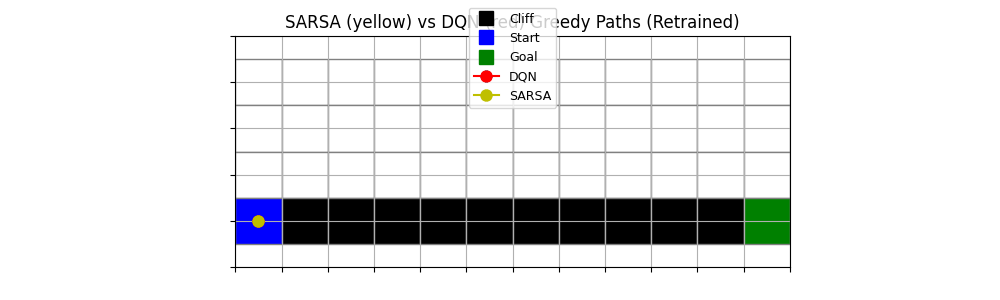

In [8]:

# Display the newly saved GIF
Image(filename='cliffwalking_paths.gif')

# Task
Modify the existing `train_Q` function to incorporate First-Visit Monte Carlo control, train Q-learning, SARSA, and Monte Carlo agents with consistent hyperparameters, extract and display their optimal paths and total rewards, and update the animation to visualize all three agents' paths simultaneously with an updated legend and title.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import gymnasium as gym

# Environment setup
env = gym.make('CliffWalking-v1', render_mode=None)
n_states = env.observation_space.n
n_actions = env.action_space.n

# Define num_episodes before it's used in train_Q's default arguments
num_episodes=5000

def train_Q(env, alpha=0.2, gamma=0.99, initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, episodes=num_episodes, algo='qlearning'):
    Q = np.zeros((n_states, n_actions))
    epsilon = initial_epsilon

    # Monte Carlo specific initializations
    if algo == 'monte_carlo':
        returns_sum = np.zeros((n_states, n_actions))
        N = np.zeros((n_states, n_actions))

    for ep in range(episodes):
        state, _ = env.reset()
        done = False

        # Initialize episode data for Monte Carlo
        if algo == 'monte_carlo':
            episode_data = []

        while not done:
            if np.random.rand() < epsilon:
                action = np.random.choice(n_actions)
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Collect episode data for Monte Carlo
            if algo == 'monte_carlo':
                episode_data.append((state, action, reward))

            if algo == 'sarsa':
                # SARSA is on-policy, so it uses the *next* action taken by the current (exploratory) policy
                if np.random.rand() < epsilon:
                    next_action = np.random.choice(n_actions)
                else:
                    next_action = np.argmax(Q[next_state])
                td_target = reward + gamma * Q[next_state, next_action] * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
            elif algo == 'qlearning':  # Q-learning (DQN-style off-policy update)
                # Q-learning is off-policy, it considers the best possible action from next_state
                td_target = reward + gamma * np.max(Q[next_state]) * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state

        # Monte Carlo update after episode concludes - this must be an 'if' and outside the while loop
        if algo == 'monte_carlo':
            G = 0
            visited_sa = set()
            for t in reversed(range(len(episode_data))):
                state_t, action_t, reward_t = episode_data[t]
                G = gamma * G + reward_t
                if (state_t, action_t) not in visited_sa:
                    visited_sa.add((state_t, action_t))
                    N[state_t, action_t] += 1
                    returns_sum[state_t, action_t] += G
                    Q[state_t, action_t] = returns_sum[state_t, action_t] / N[state_t, action_t]

        epsilon = max(min_epsilon, epsilon * epsilon_decay) # Decay epsilon after each episode
    return Q

# Train both agents with updated parameters
# Increased episodes, added initial_epsilon, min_epsilon, and epsilon_decay
Q_sarsa = train_Q(env, episodes=num_episodes, algo='sarsa', initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, alpha=0.2, gamma=0.99)
Q_dqn = train_Q(env, episodes=num_episodes, algo='qlearning', initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, alpha=0.2, gamma=0.99)
Q_mc = train_Q(env, episodes=num_episodes, algo='monte_carlo', initial_epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.999, alpha=0.2, gamma=0.99)

def greedy_path(Q):
    path = []
    total_reward = 0 # Initialize total reward
    state, _ = env.reset()
    done = False
    steps = 0
    while not done and steps < 50: # Limit steps to prevent infinite loops in bad policies
        y, x = divmod(state, 12)
        path.append( (y, x) )
        action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward # Accumulate reward
        state = next_state
        done = terminated or truncated
        steps += 1
    # Add final state if not already added (e.g., if goal was reached in last step)
    y, x = divmod(state, 12)
    if not path or path[-1] != (y,x):
        path.append( (y, x) )
    return path, total_reward # Return both path and total_reward

# Get new paths and rewards after retraining
sarsa_path, sarsa_reward = greedy_path(Q_sarsa)
dqn_path, dqn_reward = greedy_path(Q_dqn)
mc_path, mc_reward = greedy_path(Q_mc)

# --- Added print statements to clarify paths and rewards ---
print(f"DQN Path: {dqn_path}, Total Reward: {dqn_reward}")
print(f"SARSA Path: {sarsa_path}, Total Reward: {sarsa_reward}")
print(f"Monte Carlo Path: {mc_path}, Total Reward: {mc_reward}")
# ------------------------------------------------

# Setup gridworld visual (remains the same)
grid = np.full((4, 12), '.')
grid[3, 0] = 'S'
grid[3, 11] = 'G'
grid[3, 1:11] = 'C'

# Increased figsize for a larger animation
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xticks(np.arange(-0.5, 12, 1))
# ax.set_yticks(np.arange(-0.5, 4, 1)) # This will be adjusted in draw_grid
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True)

# Draw base grid (remains the same)
colors = {'.' : 'white', 'C':'black', 'S':'blue', 'G':'green'}
def draw_grid():
    ax.clear()
    for i in range(4):
        for j in range(12):
            c = grid[i, j]
            # Adjusted y-coordinate to align grid cells correctly
            rect = plt.Rectangle([j-0.5,3-i], 1, 1, facecolor=colors[c], edgecolor='gray')
            ax.add_patch(rect)
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-0.5, 4.5) # Adjusted y-limits to fit all cells and borders
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_xticks(np.arange(-0.5, 12, 1))
    ax.set_yticks(np.arange(-0.5, 5, 1)) # Adjusted y-ticks for proper grid lines
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # Add legend for cliff, S, G manually
    ax.plot([], [], 'sk', markersize=10, label='Cliff')
    ax.plot([], [], 'sb', markersize=10, label='Start')
    ax.plot([], [], 'sg', markersize=10, label='Goal')

# Animation update logic (remains the same)
max_len = max(len(dqn_path), len(sarsa_path), len(mc_path))
def update(frame):
    draw_grid()
    # Plot Q-learning/DQN path in red
    for k in range(min(len(dqn_path), frame+1)):
        y, x = dqn_path[k]
        # Adjusted y-coordinate to center path points in cells
        ax.plot(x, 3.5-y, 'ro-', label='DQN' if k == 0 else "", markersize=8)
    # Plot SARSA path in yellow
    for k in range(min(len(sarsa_path), frame+1)):
        y, x = sarsa_path[k]
        # Adjusted y-coordinate to center path points in cells
        ax.plot(x, 3.5-y, 'yo-', label='SARSA' if k == 0 else "", markersize=8)
    # Plot Monte Carlo path in green
    for k in range(min(len(mc_path), frame+1)):
        y, x = mc_path[k]
        # Adjusted y-coordinate to center path points in cells
        ax.plot(x, 3.5-y, 'go-', label='Monte Carlo' if k == 0 else "", markersize=8)
    # Only add label once
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # Moved legend to 'upper center' and used bbox_to_anchor to position it above the plot
    ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.15), fontsize=9)
    ax.set_title('SARSA (yellow) vs DQN (red) vs Monte Carlo (green) Greedy Paths (Retrained)')

ani = FuncAnimation(fig, update, frames=max_len, interval=500, repeat=False)
plt.close(fig) # Close the plot figure created by FuncAnimation to prevent it from displaying twice

DQN Path: [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)], Total Reward: -13
SARSA Path: [(3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)], Total Reward: -17
Monte Carlo Path: [(3, 0), (2, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)], Total Reward: -17
